In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file_path=r'C:\Project\AIML\Crop_Production_Prediction\Excel_Data\FAOSTAT_data.xlsx'    # paste the file path
df = pd.read_excel(file_path)
df.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,4,Afghanistan,5312,Area harvested,1371,"Almonds, in shell",2019,2019,ha,29203.0,A,Official figure,NaN
1,QCL,Crops and livestock products,4,Afghanistan,5412,Yield,1371,"Almonds, in shell",2019,2019,kg/ha,1308.3,A,Official figure,NaN
2,QCL,Crops and livestock products,4,Afghanistan,5510,Production,1371,"Almonds, in shell",2019,2019,t,38205.0,A,Official figure,NaN
3,QCL,Crops and livestock products,4,Afghanistan,5312,Area harvested,1371,"Almonds, in shell",2020,2020,ha,22134.0,A,Official figure,NaN
4,QCL,Crops and livestock products,4,Afghanistan,5412,Yield,1371,"Almonds, in shell",2020,2020,kg/ha,1775.9,A,Official figure,NaN


In [3]:
df['Element (Unit)'] = df['Element'] + " (" + df['Unit'] + ")"

In [4]:
pivot_df = df.pivot_table(
    index=["Domain Code", "Domain", "Area Code (M49)", "Area", "Item Code (CPC)", "Item", "Year","Flag"],
    columns="Element",
    values="Value",
    aggfunc="first"  # Use below depending on your data,
    #'first': Take the first value
    #'sum': Add them
    #'mean': Take the average
    #list: Return all values as a list
)

# Flatten column headers
pivot_df.columns.name = None
pivot_df.reset_index(inplace=True)

pivot_df.head()

,Domain Code,Domain,Area Code (M49),Area,Item Code (CPC),Item,Year,Flag,Area harvested,Laying,Milk Animals,Producing Animals/Slaughtered,Production,Stocks,Yield,Yield/Carcass Weight
0,QCL,Crops and livestock products,4,Afghanistan,0,Grapes,2021,A,NaN,NaN,NaN,NaN,NaN,NaN,10727.9,NaN
1,QCL,Crops and livestock products,4,Afghanistan,111,Wheat,2019,A,2334000.0,NaN,NaN,NaN,4890000.0,NaN,2095.1,NaN
2,QCL,Crops and livestock products,4,Afghanistan,111,Wheat,2020,A,2668000.0,NaN,NaN,NaN,5185000.0,NaN,1943.4,NaN
3,QCL,Crops and livestock products,4,Afghanistan,111,Wheat,2021,A,2046564.0,NaN,NaN,NaN,4017657.0,NaN,1963.1,NaN
4,QCL,Crops and livestock products,4,Afghanistan,111,Wheat,2022,A,1859339.0,NaN,NaN,NaN,3802895.0,NaN,2045.3,NaN


In [5]:
print("Rows:", pivot_df.shape[0], "Columns:", pivot_df.shape[1])

Rows: 125176 Columns: 16


In [6]:
print("\nColumns:")
print(pivot_df.columns.tolist())



Columns:
['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Item Code (CPC)', 'Item', 'Year', 'Flag', 'Area harvested', 'Laying', 'Milk Animals', 'Producing Animals/Slaughtered', 'Production', 'Stocks', 'Yield', 'Yield/Carcass Weight']


In [7]:
pivot_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125176 entries, 0 to 125175
Data columns (total 16 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Domain Code                    125176 non-null  object 
 1   Domain                         125176 non-null  object 
 2   Area Code (M49)                125176 non-null  int64  
 3   Area                           125176 non-null  object 
 4   Item Code (CPC)                125176 non-null  object 
 5   Item                           125176 non-null  object 
 6   Year                           125176 non-null  int64  
 7   Flag                           125176 non-null  object 
 8   Area harvested                 47898 non-null   float64
 9   Laying                         1063 non-null    float64
 10  Milk Animals                   2108 non-null    float64
 11  Producing Animals/Slaughtered  17563 non-null   float64
 12  Production                    

In [8]:
pivot_df.describe()

,Area Code (M49),Year,Area harvested,Laying,Milk Animals,Producing Animals/Slaughtered,Production,Stocks,Yield,Yield/Carcass Weight
count,125176.000000,125176.000000,4.789800e+04,1.063000e+03,2.108000e+03,1.756300e+04,8.226400e+04,8.600000e+03,50686.000000,6307.000000
mean,427.049658,2020.958650,1.712897e+05,5.441175e+04,2.097844e+06,3.985210e+06,8.860056e+05,3.619743e+06,13527.024261,8884.707309
std,254.341845,1.398838,1.430002e+06,3.172641e+05,5.929932e+06,2.995127e+07,1.020942e+07,1.974355e+07,28653.910742,23065.217256
min,4.000000,2019.000000,0.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,56.000000
25%,203.000000,2020.000000,2.900000e+02,5.855000e+02,5.453875e+04,8.969000e+03,8.048075e+02,4.086000e+03,1474.050000,235.000000
50%,410.000000,2021.000000,3.007000e+03,4.080000e+03,3.130900e+05,1.255670e+05,1.059999e+04,6.626250e+04,5434.750000,1482.000000
75%,643.000000,2022.000000,2.325975e+04,1.712350e+04,1.345444e+06,1.056920e+06,9.682900e+04,8.914400e+05,14875.225000,10015.500000
max,894.000000,2023.000000,4.783200e+07,3.368567e+06,6.359617e+07,7.356545e+08,7.825858e+08,4.579971e+08,705196.700000,500000.000000


In [9]:
# Strip whitespaces from column names
pivot_df.columns = pivot_df.columns.str.strip()

In [10]:
# Standardize column names (optional, for consistency)
pivot_df.columns = pivot_df.columns.str.lower().str.replace(' ', '_').str.replace('(',' ').str.replace(')','')

In [11]:
missing = pivot_df.isnull().sum()
missing[missing > 0]

area_harvested                    77278
laying                           124113
milk_animals                     123068
producing_animals/slaughtered    107613
production                        42912
stocks                           116576
yield                             74490
yield/carcass_weight             118869
dtype: int64

In [12]:
# Percentage of missing values
print((pivot_df.isnull().mean() * 100).sort_values(ascending=False))

laying                           99.150796
milk_animals                     98.315971
yield/carcass_weight             94.961494
stocks                           93.129673
producing_animals/slaughtered    85.969355
area_harvested                   61.735476
yield                            59.508212
production                       34.281332
domain_code                       0.000000
domain                            0.000000
area_code_ m49                    0.000000
area                              0.000000
item_code_ cpc                    0.000000
item                              0.000000
year                              0.000000
flag                              0.000000
dtype: float64


In [13]:
# Drop columns with too many missing values (e.g., >50%)
threshold = 0.7
pivot_df = pivot_df.loc[:, pivot_df.isnull().mean() < threshold]

In [14]:
pivot_df.isnull().sum()

domain_code           0
domain                0
area_code_ m49        0
area                  0
item_code_ cpc        0
item                  0
year                  0
flag                  0
area_harvested    77278
production        42912
yield             74490
dtype: int64

In [15]:
pivot_df.duplicated().sum()

0

In [16]:
mean_value = pivot_df['area_harvested'].mean()
pivot_df.loc[:,'area_harvested'] = pivot_df['area_harvested'].fillna(mean_value)

In [17]:
mean_value = pivot_df['production'].mean()
pivot_df.loc[:,'production'] = pivot_df['production'].fillna(mean_value)

In [18]:
mean_value = pivot_df['yield'].mean()
pivot_df.loc[:,'yield'] = pivot_df['yield'].fillna(mean_value)

In [19]:
pivot_df.isnull().sum()

domain_code       0
domain            0
area_code_ m49    0
area              0
item_code_ cpc    0
item              0
year              0
flag              0
area_harvested    0
production        0
yield             0
dtype: int64

In [20]:
pivot_df.head()

,domain_code,domain,area_code_ m49,area,item_code_ cpc,item,year,flag,area_harvested,production,yield
0,QCL,Crops and livestock products,4,Afghanistan,0,Grapes,2021,A,1.712897e+05,8.860056e+05,10727.9
1,QCL,Crops and livestock products,4,Afghanistan,111,Wheat,2019,A,2.334000e+06,4.890000e+06,2095.1
2,QCL,Crops and livestock products,4,Afghanistan,111,Wheat,2020,A,2.668000e+06,5.185000e+06,1943.4
3,QCL,Crops and livestock products,4,Afghanistan,111,Wheat,2021,A,2.046564e+06,4.017657e+06,1963.1
4,QCL,Crops and livestock products,4,Afghanistan,111,Wheat,2022,A,1.859339e+06,3.802895e+06,2045.3


In [21]:
pivot_df.rename(columns={
    'area_code_ m49': 'area_code',
    'item_code_ cpc': 'item_code'
}, inplace=True)


In [22]:
cols_to_clean = ['area_harvested', 'production', 'yield']

for col in cols_to_clean:
    pivot_df.loc[:, col] = pivot_df[col].astype(str).str.replace(',', '').astype(float)

In [23]:
pivot_df.head()

,domain_code,domain,area_code,area,item_code,item,year,flag,area_harvested,production,yield
0,QCL,Crops and livestock products,4,Afghanistan,0,Grapes,2021,A,1.712897e+05,8.860056e+05,10727.9
1,QCL,Crops and livestock products,4,Afghanistan,111,Wheat,2019,A,2.334000e+06,4.890000e+06,2095.1
2,QCL,Crops and livestock products,4,Afghanistan,111,Wheat,2020,A,2.668000e+06,5.185000e+06,1943.4
3,QCL,Crops and livestock products,4,Afghanistan,111,Wheat,2021,A,2.046564e+06,4.017657e+06,1963.1
4,QCL,Crops and livestock products,4,Afghanistan,111,Wheat,2022,A,1.859339e+06,3.802895e+06,2045.3


In [24]:
pivot_df['area_harvested'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 125176 entries, 0 to 125175
Series name: area_harvested
Non-Null Count   Dtype  
--------------   -----  
125176 non-null  float64
dtypes: float64(1)
memory usage: 978.1 KB


In [25]:
pivot_df['area_harvested'].describe()

count    1.251760e+05
mean     1.712897e+05
std      8.845697e+05
min      0.000000e+00
25%      1.000000e+04
50%      1.712897e+05
75%      1.712897e+05
max      4.783200e+07
Name: area_harvested, dtype: float64

In [26]:
pivot_df['area_harvested'] = pivot_df['area_harvested'].apply(lambda x: float(x))
pivot_df['area_harvested'] = pivot_df['area_harvested'].round(2)
pivot_df['area_harvested'] = pivot_df['area_harvested'].apply(lambda x: f"{x:,.0f}")


In [27]:
pivot_df['production'] = pivot_df['production'].apply(lambda x: float(x))
pivot_df['production'] = pivot_df['production'].round(2)
pivot_df['production'] = pivot_df['production'].apply(lambda x: f"{x:,.0f}")

In [28]:
pivot_df['yield'] = pivot_df['yield'].apply(lambda x: float(x))
pivot_df['yield'] = pivot_df['yield'].round(2)
pivot_df['yield'] = pivot_df['yield'].apply(lambda x: f"{x:,.0f}")

In [ ]:
pivot_df['area_harvested'] = pivot_df['area_harvested'].replace(',', '', regex=True).astype(float)
pivot_df['production'] = pivot_df['production'].replace(',', '', regex=True).astype(float)
pivot_df['yield'] = pivot_df['yield'].replace(',', '', regex=True).astype(float)

In [30]:
pivot_df.head()

,domain_code,domain,area_code,area,item_code,item,year,flag,area_harvested,production,yield
0,QCL,Crops and livestock products,4,Afghanistan,0,Grapes,2021,A,171290.0,886006.0,10728.0
1,QCL,Crops and livestock products,4,Afghanistan,111,Wheat,2019,A,2334000.0,4890000.0,2095.0
2,QCL,Crops and livestock products,4,Afghanistan,111,Wheat,2020,A,2668000.0,5185000.0,1943.0
3,QCL,Crops and livestock products,4,Afghanistan,111,Wheat,2021,A,2046564.0,4017657.0,1963.0
4,QCL,Crops and livestock products,4,Afghanistan,111,Wheat,2022,A,1859339.0,3802895.0,2045.0


In [37]:
pivot_df['area_harvested_k'] = pivot_df['area_harvested'] / 1000
pivot_df['production_k'] = pivot_df['production'] / 1000
pivot_df['yield_k'] = pivot_df['yield'] / 1000

In [38]:
pivot_df.head()

,domain_code,domain,area_code,area,item_code,item,year,flag,area_harvested,production,yield,area_harvested_k,production_k,yield_k
0,QCL,Crops and livestock products,4,Afghanistan,0,Grapes,2021,A,171290.0,886006.0,10728.0,171.290,886.006,10.728
1,QCL,Crops and livestock products,4,Afghanistan,111,Wheat,2019,A,2334000.0,4890000.0,2095.0,2334.000,4890.000,2.095
2,QCL,Crops and livestock products,4,Afghanistan,111,Wheat,2020,A,2668000.0,5185000.0,1943.0,2668.000,5185.000,1.943
3,QCL,Crops and livestock products,4,Afghanistan,111,Wheat,2021,A,2046564.0,4017657.0,1963.0,2046.564,4017.657,1.963
4,QCL,Crops and livestock products,4,Afghanistan,111,Wheat,2022,A,1859339.0,3802895.0,2045.0,1859.339,3802.895,2.045


In [39]:
pivot_df['area'].value_counts()

area
China, mainland               1532
South Africa                  1231
Chile                         1158
Iran (Islamic Republic of)    1142
Tunisia                       1103
                              ... 
Kiribati                       121
Tuvalu                         115
Faroe Islands                  101
Tokelau                         98
Marshall Islands                14
Name: count, Length: 200, dtype: int64

In [40]:
pivot_df['domain'].value_counts()

domain
Crops and livestock products    125176
Name: count, dtype: int64

In [41]:
pivot_df['item'].value_counts()

item
Raw hides and skins of cattle            2142
Raw hides and skins of sheep or lambs    1894
Meat of chickens, fresh or chilled       1828
Raw hides and skins of goats or kids     1823
Hen eggs in shell, fresh                 1624
                                         ... 
Other rodents                              10
Other camelids                             10
Jojoba seeds                               10
Kapok fibre, raw                            8
Kapokseed in shell                          8
Name: count, Length: 275, dtype: int64

In [42]:
pivot_df['flag'].value_counts()

flag
A    48780
I    39047
E    32791
X     4558
Name: count, dtype: int64

In [43]:
pivot_df['area_harvested'].min(), pivot_df['area_harvested'].max()

(0.0, 47832000.0)

In [44]:
pivot_df['area_harvested_k'].min(), pivot_df['area_harvested_k'].max()

(0.0, 47832.0)

In [45]:
pivot_df['production'].min(), pivot_df['production'].max()

(0.0, 782585836.0)

In [46]:
pivot_df['production_k'].min(), pivot_df['production_k'].max()

(0.0, 782585.836)

In [47]:
pivot_df['yield'].min(), pivot_df['yield'].max()

(0.0, 705197.0)

In [48]:
pivot_df['yield_k'].min(), pivot_df['yield_k'].max()

(0.0, 705.197)

In [51]:
pivot_df['area'].value_counts()

area
China, mainland               1532
South Africa                  1231
Chile                         1158
Iran (Islamic Republic of)    1142
Tunisia                       1103
                              ... 
Kiribati                       121
Tuvalu                         115
Faroe Islands                  101
Tokelau                         98
Marshall Islands                14
Name: count, Length: 200, dtype: int64

In [52]:
pivot_df['item'].min(), pivot_df['item'].max()

('Abaca, manila hemp, raw', 'Yoghurt')

In [53]:
pivot_df['item_code'].describe()

count     125176.00
unique       276.00
top         2951.01
freq        2142.00
Name: item_code, dtype: float64

In [57]:
pivot_df.head()

,domain_code,domain,area_code,area,item_code,item,year,flag,area_harvested,production,yield,area_harvested_k,production_k,yield_k
0,QCL,Crops and livestock products,4,Afghanistan,0,Grapes,2021,A,171290.0,886006.0,10728.0,171.290,886.006,10.728
1,QCL,Crops and livestock products,4,Afghanistan,111,Wheat,2019,A,2334000.0,4890000.0,2095.0,2334.000,4890.000,2.095
2,QCL,Crops and livestock products,4,Afghanistan,111,Wheat,2020,A,2668000.0,5185000.0,1943.0,2668.000,5185.000,1.943
3,QCL,Crops and livestock products,4,Afghanistan,111,Wheat,2021,A,2046564.0,4017657.0,1963.0,2046.564,4017.657,1.963
4,QCL,Crops and livestock products,4,Afghanistan,111,Wheat,2022,A,1859339.0,3802895.0,2045.0,1859.339,3802.895,2.045


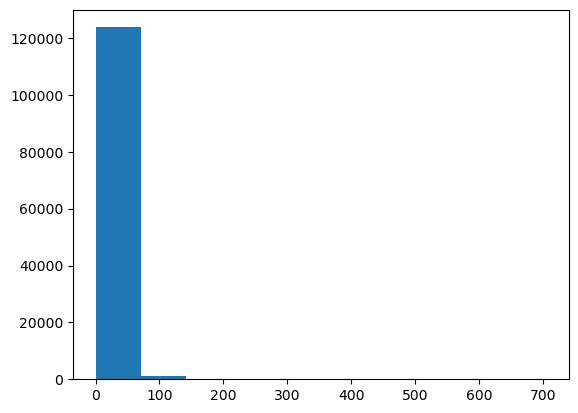

In [55]:
plt.hist(pivot_df['yield_k'])
plt.show()

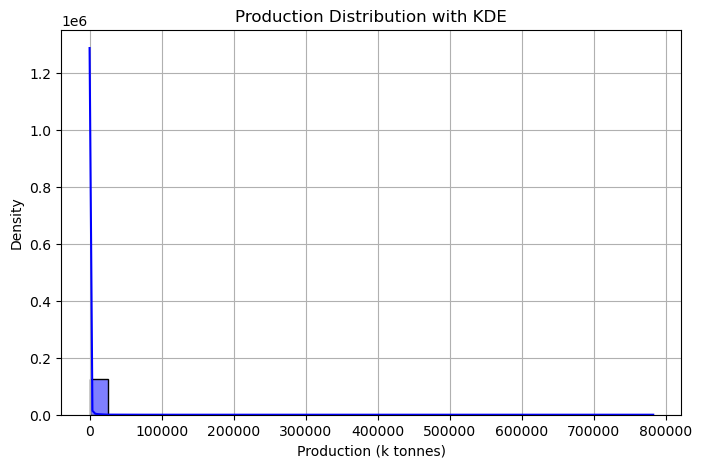

In [80]:
plt.figure(figsize=(8, 5))
sns.histplot(pivot_df['production_k'], bins=30, kde=True, color='blue')
plt.title('Production Distribution with KDE')
plt.xlabel('Production (k tonnes)')
plt.ylabel('Density')
plt.grid(True)
plt.show()


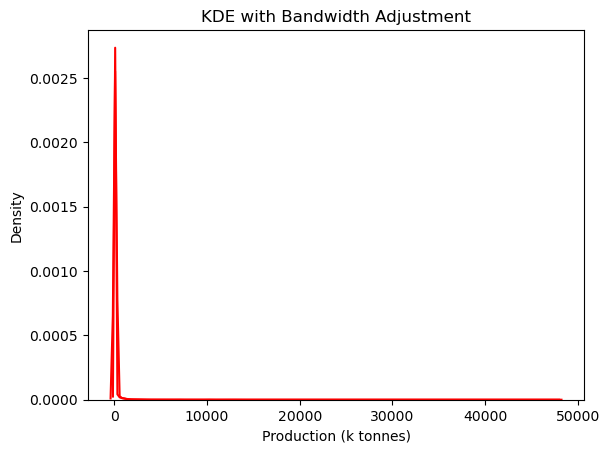

In [86]:
sns.kdeplot(pivot_df['area_harvested_k'], bw_adjust=0.5,color='red')  # Lower = sharper
sns.kdeplot(pivot_df['area_harvested_k'], bw_adjust=1.5,color='red')  # Higher = smoother
plt.title('KDE with Bandwidth Adjustment')
plt.xlabel('Area Harvested (k tonnes)')
plt.show()


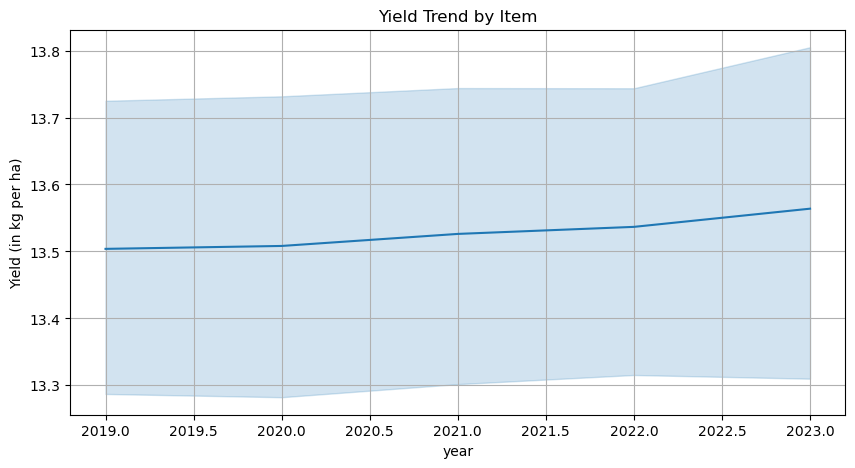

In [60]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=pivot_df, x='year', y='yield_k')
plt.title('Yield Trend by Item')
plt.ylabel('Yield (in kg per ha)')
plt.grid(True)
plt.show()


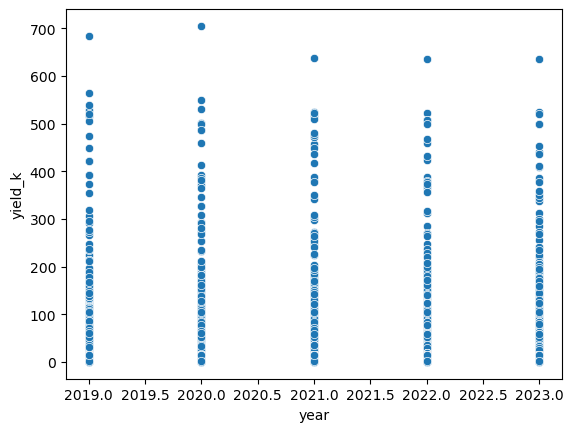

In [74]:
sns.scatterplot(data=pivot_df, x="year", y="yield_k")
plt.show()

In [65]:
import plotly.express as px

fig = px.pie(pivot_df, names='area', values='area_harvested',
             title='Interactive Pie Chart: Area Harvested by Region')
fig.show()


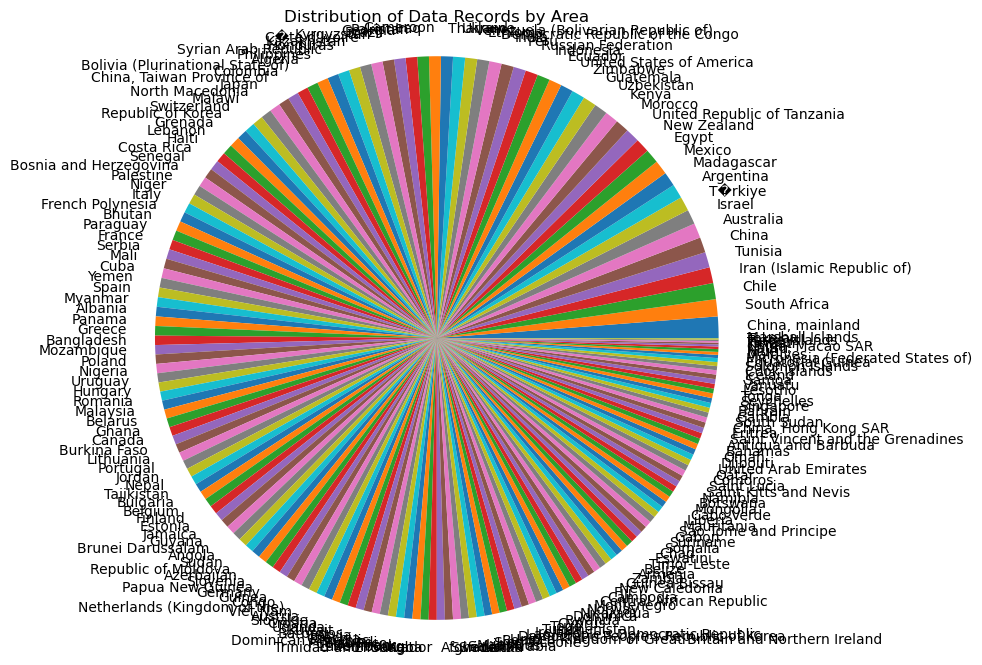

In [78]:
area_counts = pivot_df['area'].value_counts()

# Plot
plt.figure(figsize=(8, 8)) 
plt.pie(area_counts, labels=area_counts.index)  #, autopct='%1.1f%%', startangle=140
plt.title('Distribution of Data Records by Area')
plt.axis('equal')  # Equal aspect ratio ensures pie is a circle.
plt.show()

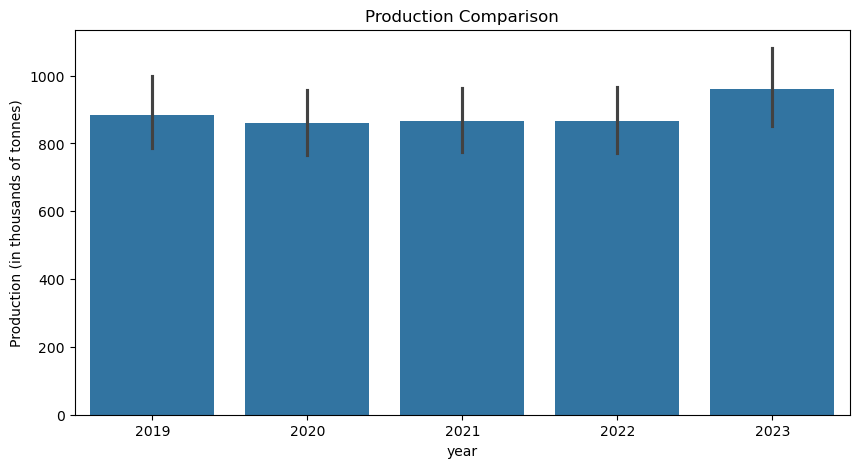

In [71]:
plt.figure(figsize=(10, 5))
sns.barplot(data=pivot_df, x='year', y='production_k')  #, hue='item'
plt.title('Production Comparison')
plt.ylabel('Production (in thousands of tonnes)')
plt.show()


In [88]:
# fig = px.choropleth(pivot_df,
#                     locations='area',
#                     locationmode='country names',
#                     color='production_k',
#                     hover_name='item',
#                     animation_frame='year',
#                     title='Production by Country Over Time',
#                     color_continuous_scale='Viridis')
# fig.show()


In [87]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

In [89]:
X = pivot_df[['area_harvested_k', 'yield_k']]
y = pivot_df['production_k']

# Train-Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    print(f"{name} Performance:")
    print(f"R² Score: {r2:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print("-" * 40)
    return {"Model": name, "R2": r2, "MSE": mse, "MAE": mae}

In [100]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_metrics = evaluate_model("Linear Regression", lr, X_test, y_test)


Linear Regression Performance:
R² Score: 0.4862
Mean Squared Error (MSE): 15152992.7783
Mean Absolute Error (MAE): 825.3747
----------------------------------------


In [101]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_metrics = evaluate_model("Random Forest", rf, X_test, y_test)


Random Forest Performance:
R² Score: 0.7437
Mean Squared Error (MSE): 7557680.1822
Mean Absolute Error (MAE): 487.2849
----------------------------------------


In [95]:
results_df = pd.DataFrame([lr_metrics, rf_metrics])
results_df

,Model,R2,MSE,MAE
0,Linear Regression,0.486214,1.515299e+07,825.374726
1,Random Forest,0.743745,7.557680e+06,487.284930


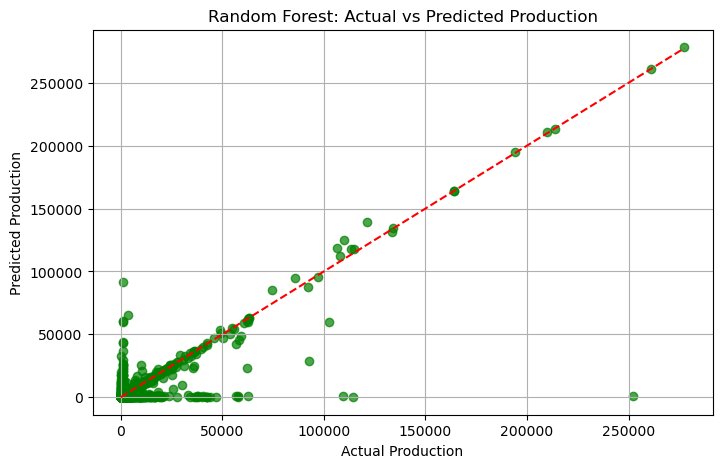

In [96]:
y_pred_rf = rf.predict(X_test)
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_rf, alpha=0.7, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Production')
plt.ylabel('Predicted Production')
plt.title('Random Forest: Actual vs Predicted Production')
plt.grid(True)
plt.show()


In [54]:
import pymysql
import mysql.connector
from mysql.connector import Error

connection = pymysql.connect(
        host='localhost',
        user='root',
        password='Test@123',
        database='Crop_Production',
        charset='utf8mb4',
        cursorclass=pymysql.cursors.DictCursor
    )


cursor = connection.cursor()
create_table_query ="""
        CREATE TABLE IF NOT EXISTS production (
                    id INT AUTO_INCREMENT PRIMARY KEY,
                    domain_code VARCHAR(10),
                    domain VARCHAR(100),
                    area_code INT,
                    area VARCHAR(50),
                    item_code VARCHAR(50),
                    item VARCHAR(200),
                    year INT,
                    flag CHAR(1),
                    area_harvested FLOAT,
                    production FLOAT,
                    yield FLOAT,
                    area_harvested_k FLOAT,
                    production_k FLOAT,
                    yield_k FLOAT
                ) 
"""
cursor.execute(create_table_query)


insert_query ='''
        INSERT INTO production (domain_code, domain, area_code, area ,item_code , item,
                        `year`, flag, area_harvested, production, yield, area_harvested_k, production_k, yield_k) 
                        VALUES (%s, %s, %s, %s, %s,
                        %s, %s, %s, %s, %s, %s, %s, %s, %s)

'''

data_to_insert = pivot_df[[
            'domain_code', 'domain', 'area_code', 'area', 'item_code', 'item',
            'year', 'flag', 'area_harvested', 'production', 'yield', 'area_harvested_k', 'production_k', 'yield_k'
]].values.tolist()


batch_size = 1000
total_rows = len(data_to_insert)

for i in range(0, total_rows, batch_size):
    batch = data_to_insert[i:i + batch_size]
    try:
        cursor.executemany(insert_query, batch)
        connection.commit()
        print(f"Inserted rows {i} to {i+len(batch)-1}")
    except Exception as e:
        print(f"Error inserting rows {i} to {i+len(batch)-1}: {e}")
        connection.rollback()

Inserted rows 0 to 999
Inserted rows 1000 to 1999
Inserted rows 2000 to 2999
Inserted rows 3000 to 3999
Inserted rows 4000 to 4999
Inserted rows 5000 to 5999
Inserted rows 6000 to 6999
Inserted rows 7000 to 7999
Inserted rows 8000 to 8999
Inserted rows 9000 to 9999
Inserted rows 10000 to 10999
Inserted rows 11000 to 11999
Inserted rows 12000 to 12999
Inserted rows 13000 to 13999
Inserted rows 14000 to 14999
Inserted rows 15000 to 15999
Inserted rows 16000 to 16999
Inserted rows 17000 to 17999
Inserted rows 18000 to 18999
Inserted rows 19000 to 19999
Inserted rows 20000 to 20999
Inserted rows 21000 to 21999
Inserted rows 22000 to 22999
Inserted rows 23000 to 23999
Inserted rows 24000 to 24999
Inserted rows 25000 to 25999
Inserted rows 26000 to 26999
Inserted rows 27000 to 27999
Inserted rows 28000 to 28999
Inserted rows 29000 to 29999
Inserted rows 30000 to 30999
Inserted rows 31000 to 31999
Inserted rows 32000 to 32999
Inserted rows 33000 to 33999
Inserted rows 34000 to 34999
Inserted 

In [ ]:
connection.close()